In [13]:
import os
import json
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# 1. EDA

## 1.1 Data importing and overview

In [14]:
meta_dir = r'..\data\raw\sashts_metadata.csv'
net_dir = r'..\data\raw\sashts_contact_network.csv'

df_meta = pd.read_csv(meta_dir)
df_net = pd.read_csv(net_dir)

In [15]:
df_meta

,indid,site,agegrp9,sex,ind_inc_ana,hhid,smokecignow1,bmicat,ixagegrp9,ixsex,ixminctcat1,ixminctcat2,sleep_room_ix,cared_by_ix,sus,ixesarsvarf1,index,sars
0,J008-001,Klerksdorp,18-34,Female,Yes,J008,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
1,J008-002,Klerksdorp,35-59,Male,Yes,J008,Yes,Overweight,18-34,Female,25-35,<30,No,No,Susceptible,non-Alpha/Beta/Delta,Contact,Negative
2,J008-004,Klerksdorp,<5,Male,Yes,J008,No,Normal weight,18-34,Female,25-35,<30,Yes,Yes,Susceptible,non-Alpha/Beta/Delta,Contact,Positive
3,J008-005,Klerksdorp,12-May,Female,Yes,J008,No,Normal weight,18-34,Female,25-35,<30,Yes,No,Susceptible,non-Alpha/Beta/Delta,Contact,Positive
4,J008-006,Klerksdorp,13-17,Female,Yes,J008,No,Normal weight,18-34,Female,25-35,<30,Yes,No,Susceptible,non-Alpha/Beta/Delta,Contact,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,S080-001,Soweto,18-34,Male,Yes,S080,Yes,Normal weight,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
336,S080-002,Soweto,35-59,Male,Yes,S080,Yes,Normal weight,18-34,Male,>35,>35,No,No,Susceptible,Variant Unknown,Contact,Negative
337,S080-003,Soweto,35-59,Female,Yes,S080,No,Obese,18-34,Male,>35,>35,No,No,Susceptible,Variant Unknown,Contact,Negative
338,S081-001,Soweto,35-59,Female,Yes,S081,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive


In [16]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   indid          340 non-null    object
 1   site           340 non-null    object
 2   agegrp9        340 non-null    object
 3   sex            340 non-null    object
 4   ind_inc_ana    340 non-null    object
 5   hhid           340 non-null    object
 6   smokecignow1   340 non-null    object
 7   bmicat         340 non-null    object
 8   ixagegrp9      252 non-null    object
 9   ixsex          252 non-null    object
 10  ixminctcat1    252 non-null    object
 11  ixminctcat2    252 non-null    object
 12  sleep_room_ix  340 non-null    object
 13  cared_by_ix    340 non-null    object
 14  sus            252 non-null    object
 15  ixesarsvarf1   252 non-null    object
 16  index          340 non-null    object
 17  sars           340 non-null    object
dtypes: object(18)
memory usage: 47

In [17]:
df_net

,t,duration_sec,indid1,indid2,date,pair,hh,deployed1,collected1,deployed2,...,no_ts,sars_indid1,age_indid1,sars_indid2,age_indid2,contacts,contacts_infected,hcir,hh_ar,pair_sars
0,1/2/1970 0:18,40,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
1,1/2/1970 0:22,100,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
2,1/2/1970 0:24,20,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
3,1/2/1970 5:00,40,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
4,1/2/1970 5:42,20,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140537,5/19/2021 16:47,40,S049-005,S049-001,5/19/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission
140538,5/19/2021 16:48,20,S049-005,S049-001,5/19/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission
140539,5/19/2021 20:20,20,S049-005,S049-001,5/19/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission
140540,5/20/2021 18:23,20,S049-005,S049-001,5/20/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission


In [18]:
df_net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140542 entries, 0 to 140541
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   t                  140542 non-null  object
 1   duration_sec       140542 non-null  int64 
 2   indid1             140542 non-null  object
 3   indid2             140542 non-null  object
 4   date               140542 non-null  object
 5   pair               140542 non-null  object
 6   hh                 140542 non-null  object
 7   deployed1          140542 non-null  object
 8   collected1         140542 non-null  object
 9   deployed2          140542 non-null  object
 10  collected2         140542 non-null  object
 11  no_ts              140542 non-null  int64 
 12  sars_indid1        140542 non-null  object
 13  age_indid1         140542 non-null  object
 14  sars_indid2        140542 non-null  object
 15  age_indid2         140542 non-null  object
 16  contacts           1

## 1.2 Descriptive statistics

In [19]:
# Numeric statistics for contact network
net_num_col = ['duration_sec', 'no_ts', 'contacts', 'contacts_infected', 'hcir', 'hh_ar']

print('=== Numeric statistics: df_net ===')
display(df_net[net_num_col].describe().T)

print('=== Metadata overview: df_meta ===')
display(df_meta.describe(include='all').T)

cat_cols = ['agegrp9', 'sex', 'site', 'index', 'sars']
for col in cat_cols:
    print(f'\n[{col}] value_counts:')
    display(df_meta[col].value_counts(dropna=False).to_frame('count'))

=== Numeric statistics: df_net ===


,count,mean,std,min,25%,50%,75%,max
duration_sec,140542.0,57.044585,144.183594,20.0,20.0,20.0,60.0,14960.0
no_ts,140542.0,0.320545,0.466688,0.0,0.0,0.0,1.0,1.0
contacts,140542.0,4.238975,1.681162,1.0,3.0,4.0,5.0,8.0
contacts_infected,140542.0,2.280101,1.711097,0.0,1.0,2.0,3.0,7.0
hcir,140542.0,52.298786,34.324333,0.0,20.0,57.0,83.0,100.0
hh_ar,140542.0,62.883736,26.171867,14.0,33.0,67.0,86.0,100.0


=== Metadata overview: df_meta ===


,count,unique,top,freq
indid,340,340,J008-001,1
site,340,2,Soweto,197
agegrp9,340,6,35-59,116
sex,340,2,Female,205
ind_inc_ana,340,1,Yes,340
hhid,340,88,S007,8
smokecignow1,340,3,No,294
bmicat,340,5,Normal weight,140
ixagegrp9,252,3,35-59,137
ixsex,252,2,Female,176



[agegrp9] value_counts:


...

,count
site,
Soweto,197
Klerksdorp,143



[index] value_counts:


,count
index,
Contact,252
Index,88



[sars] value_counts:


,count
sars,
Positive,241
Negative,99


In [20]:
# Save key tabular/text EDA outputs as PNG files for reporting
from io import StringIO

def save_text_as_png(text, filename, figsize=(12, 6), fontsize=9):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.text(0.01, 0.99, text, va='top', ha='left', family='monospace', fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_dataframe_as_png(dataframe, filename, figsize=(12, 4), fontsize=8):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    table = ax.table(
        cellText=dataframe.round(3).astype(str).values,
        colLabels=dataframe.columns,
        rowLabels=dataframe.index,
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.2)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

meta_info_buffer = StringIO()
df_meta.info(buf=meta_info_buffer)
save_text_as_png(meta_info_buffer.getvalue(), 'eda_df_meta_info.png')

net_info_buffer = StringIO()
df_net.info(buf=net_info_buffer)
save_text_as_png(net_info_buffer.getvalue(), 'eda_df_net_info.png')

save_dataframe_as_png(df_net[net_num_col].describe().T, 'eda_df_net_describe.png')

## 1.3 Univariate EDA

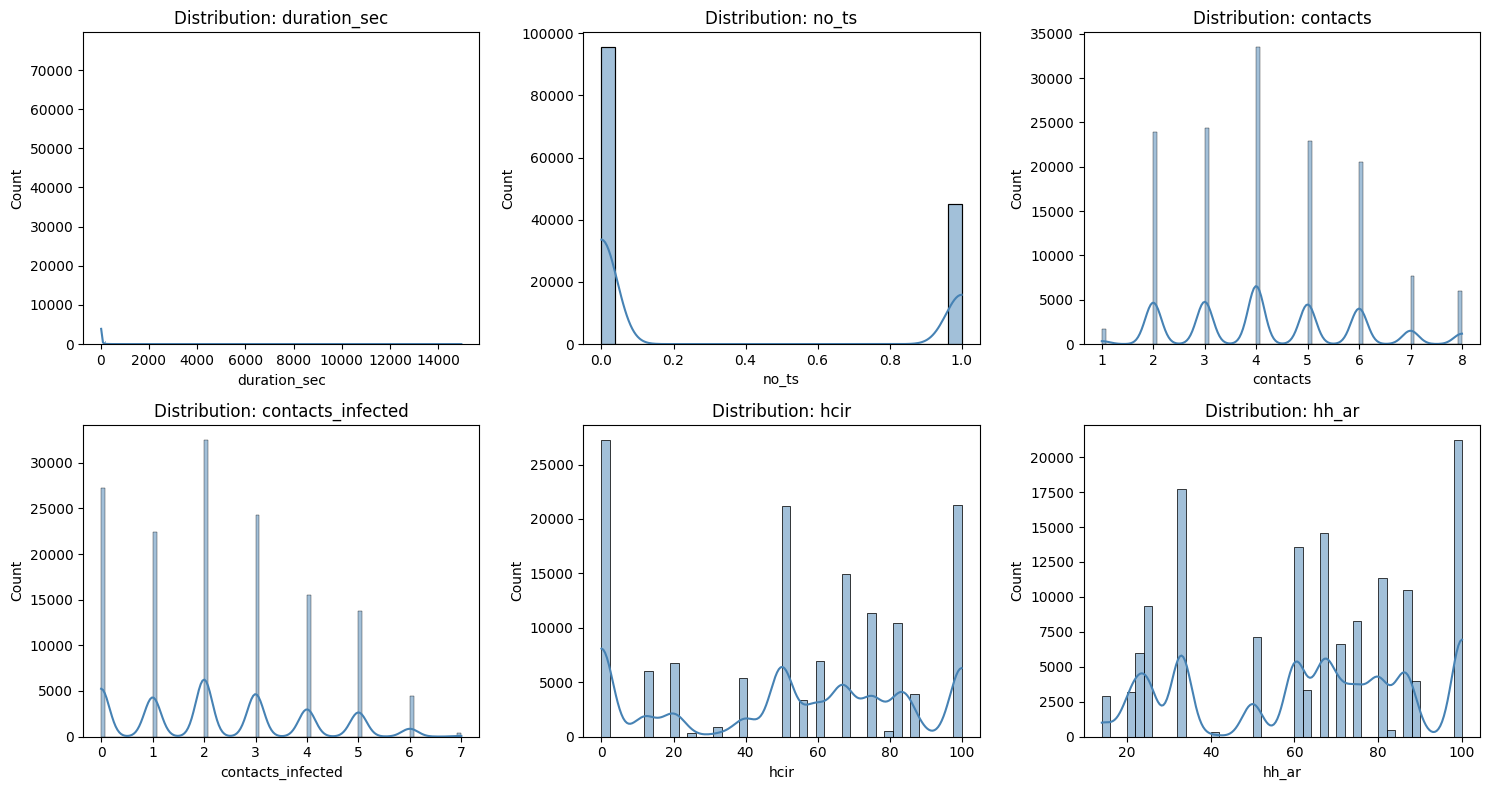

In [21]:
# Distribution of numeric variables in contact network
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), net_num_col):
    sns.histplot(df_net[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.savefig('eda_univariate.png', dpi=150, bbox_inches='tight')
plt.show()

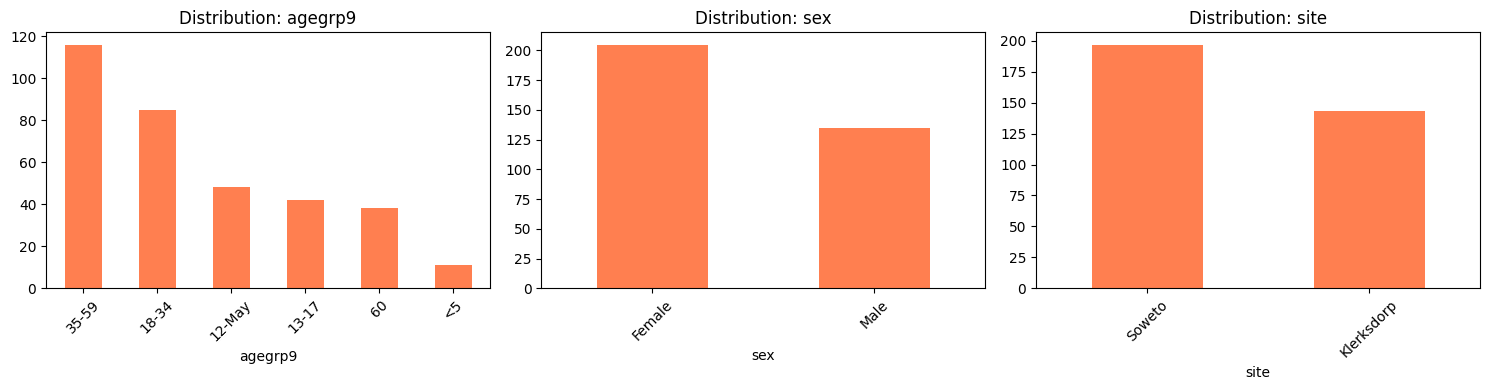

In [22]:
# Distribution of key categorical variables in metadata
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['agegrp9', 'sex', 'site']):
    df_meta[col].value_counts(dropna=False).plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Distribution: {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Correlation analysis

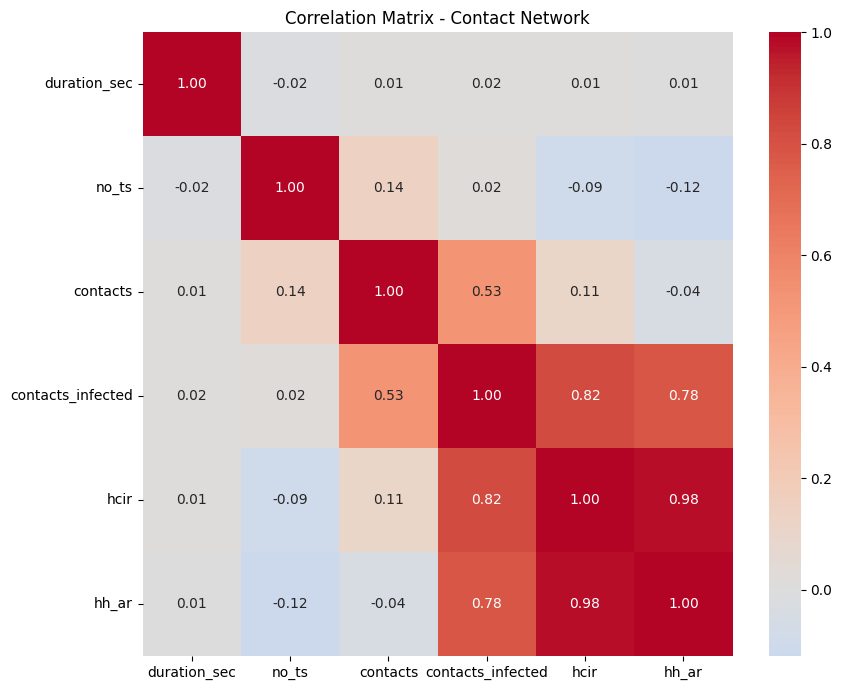

In [23]:
# Correlation matrix for numeric contact-network variables
corr = df_net[net_num_col].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Contact Network')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. ETL

## 2.1 Execute ETL pipeline from script

In [24]:
from pathlib import Path
import sys

project_root = Path.cwd()
if not (project_root / 'scripts').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [26]:
from scripts.etl import run_etl

output_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else project_root / 'data' / 'processed'
etl_outputs = run_etl(df_meta, df_net, output_dir=output_dir, save_artifacts=True)

df_meta = etl_outputs['df_meta_cleaned']

print(f"Number of F0: {len(etl_outputs['f0_records'])} ca")
print("Consistency/Range Check:")
print(etl_outputs['validation_report'])

print("Tracking outliers outside bounds:")
display(etl_outputs['outlier_summary'])

print("Result after preprocessing:")
for col in etl_outputs['sorted_dim_cols']:
    print(f"- {col}: {etl_outputs['cardinalities'][col]} unique values")

print("DF_all size:", etl_outputs['df_all'].shape)
print("DF_result size:", etl_outputs['df_result'].shape)
print("Values in Result Table:")
display(etl_outputs['df_result'].head())

print(f"Output saved to: {output_dir}")
print(etl_outputs['saved_paths'])

Number of F0: 88 ca
Consistency/Range Check:
{'metadata_id_count': 340, 'network_id_count': 340, 'ids_in_net_not_in_meta': set(), 'ids_in_meta_not_in_net': set(), 'hcir_out_of_range_count': 0, 'hh_ar_out_of_range_count': 0, 'total_out_of_range_count': 0}
Tracking outliers outside bounds:


,Column,Lower Bound,Upper Bound,Outliers Count
0,duration_sec,-40.0,120.0,10370
1,no_ts,-1.5,2.5,0
2,contacts,0.0,8.0,0
3,contacts_infected,-2.0,6.0,380
4,hcir,-74.5,177.5,0
5,hh_ar,-46.5,165.5,0


Result after preprocessing:
- ind1_site: 2 unique values
- ind1_sex: 2 unique values
- ind1_index: 2 unique values
- ind1_sars: 2 unique values
- ind1_sus: 2 unique values
- ind2_site: 2 unique values
- ind2_sex: 2 unique values
- ind2_index: 2 unique values
- ind2_sars: 2 unique values
- ind2_sus: 2 unique values
- pair_sars: 3 unique values
- ind1_smokecignow1: 3 unique values
- ind2_smokecignow1: 3 unique values
- ind1_bmicat: 5 unique values
- ind2_bmicat: 5 unique values
- ind1_agegrp9: 6 unique values
- ind1_ixesarsvarf1: 6 unique values
- ind2_agegrp9: 6 unique values
- ind2_ixesarsvarf1: 6 unique values
- month_id: 11 unique values
DF_all size: (140542, 34)
DF_result size: (140542, 26)
Values in Result Table:


,ind1_site,ind1_sex,ind1_index,ind1_sars,ind1_sus,ind2_site,ind2_sex,ind2_index,ind2_sars,ind2_sus,...,ind1_ixesarsvarf1,ind2_agegrp9,ind2_ixesarsvarf1,month_id,duration_sec,no_ts,contacts,contacts_infected,hcir,hh_ar
0,0,1,0,0,1,0,0,1,1,0,...,1,2,3,197001,40,1,4,2,50,60
1,0,1,0,0,1,0,0,1,1,0,...,1,2,3,197001,100,1,4,2,50,60
2,0,1,0,0,1,0,0,1,1,0,...,1,2,3,197001,20,1,4,2,50,60
3,0,1,0,0,1,0,0,1,1,0,...,1,2,3,197001,40,1,4,2,50,60
4,0,1,0,0,1,0,0,1,1,0,...,1,2,3,197001,20,1,4,2,50,60


Output saved to: c:\Users\duong\Downloads\Spatiotemporal-Epidemic-Prediction\data\processed
{'mapping_json': WindowsPath('c:/Users/duong/Downloads/Spatiotemporal-Epidemic-Prediction/data/processed/mapping_dict.json'), 'final_csv': WindowsPath('c:/Users/duong/Downloads/Spatiotemporal-Epidemic-Prediction/data/processed/sashts_final_dataset.csv')}


## 2.2 ETL preprocessing pipeline

```mermaid
graph TD
    A[Raw CSV: metadata + contact_network] --> B[Identify F0 records and fill categorical nulls as Self Index]
    B --> C[Fix agegrp9 format: 12-May to 5-12, 60 to >=60]
    C --> D[Cross-dataset consistency check: metadata IDs vs network IDs]
    D --> E[Range validation: hcir and hh_ar in 0-100]
    E --> F[Outlier detection with IQR]
    F --> G[Capping / winsorization]
    G --> H[Build star schema: dimensions + fact table]
    H --> I[Integer encoding for categorical columns]
    I --> J[Dimension ordering by cardinality]
    J --> K[df_result ready for Star Cubing]
```

## 2.3 Star schema ERD

```mermaid
erDiagram
    DIM_INDIVIDUAL {
        string indid PK
        string site
        string agegrp9
        string sex
        string hhid
        string index
        string sars
    }
    DIM_HOUSEHOLD {
        string hhid PK
        number hcir
        number hh_ar
        number contacts
        number contacts_infected
    }
    DIM_DATE {
        number date_id PK
        string date
        number year
        number month
        number day
    }
    DIM_PAIR {
        string pair PK
        string indid1 FK
        string indid2 FK
        string pair_sars
    }
    FACT_CONTACTS {
        string t
        number date_id FK
        string pair FK
        string indid1 FK
        string indid2 FK
        string hhid FK
        number duration_sec
        number no_ts
    }
    DIM_DATE ||--o{ FACT_CONTACTS : date_id
    DIM_PAIR ||--o{ FACT_CONTACTS : pair
    DIM_HOUSEHOLD ||--o{ FACT_CONTACTS : hhid
    DIM_INDIVIDUAL ||--o{ FACT_CONTACTS : indid1
    DIM_INDIVIDUAL ||--o{ FACT_CONTACTS : indid2
```